In [1]:
import pandas as pd
import numpy as np
# reading the data from the dataset(s)

sales=pd.read_csv('sales.csv',usecols=["date","item_id","quantity","price_base","store_id"])
sales


,date,item_id,quantity,price_base,store_id
0,2023-08-04,293375605257,1.000,47.86,1
1,2023-08-04,a66fdf2c0ae7,3.000,49.60,1
2,2023-08-04,daa46ef49b7a,0.822,379.00,1
3,2023-08-04,a3b49c1bf758,1.000,129.00,1
4,2023-08-04,ab611c5cef62,7.000,79.90,1
...,...,...,...,...,...
7432680,2024-09-26,542f4875a846,2.000,419.90,4
7432681,2024-09-26,3c7435256b1f,2.000,299.90,4
7432682,2024-09-26,87b794255afc,6.000,499.90,4
7432683,2024-09-26,0a832c545a6a,1.000,189.90,4


In [ ]:
# creating features(datetime feature engineering)
sales["date"] = pd.to_datetime(
    sales["date"]
)
sales["year"] = sales["date"].dt.year

sales["month"] = sales["date"].dt.month

sales["day"] = sales["date"].dt.day

sales["dayofweek"] = sales["date"].dt.dayofweek

sales["week"] = sales["date"].dt.isocalendar().week.astype(int)


sales["quarter"] = sales["date"].dt.quarter

sales["is_weekend"] = sales["dayofweek"].isin([5,6]).astype(int)

sales["dayofyear"] = sales["date"].dt.dayofyear
sales

,date,item_id,quantity,price_base,store_id,year,month,day,dayofweek,week,quarter,is_weekend,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7
2228305,2022-10-07,001829cb707d,1.0,149.90,1,2022,10,7,4,40,4,0,280,3.0,1.0,7.0,2.571429,3.300000,1.397276
2236620,2022-10-08,001829cb707d,4.0,146.67,1,2022,10,8,5,40,4,1,281,1.0,3.0,1.0,2.571429,3.100000,1.397276
2239181,2022-10-09,001829cb707d,3.0,149.90,1,2022,10,9,6,40,4,1,282,4.0,2.0,4.0,2.714286,3.200000,1.496026
2252266,2022-10-12,001829cb707d,1.0,149.90,1,2022,10,12,2,41,4,0,285,3.0,1.0,2.0,2.857143,3.166667,1.463850
2258146,2022-10-13,001829cb707d,2.0,149.90,1,2022,10,13,3,41,4,0,286,1.0,5.0,1.0,2.857143,3.133333,1.463850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7411105,2024-09-22,fffb04d8e873,2.0,104.90,4,2024,9,22,6,38,3,1,266,1.0,1.0,1.0,1.000000,1.333333,0.000000
7416282,2024-09-23,fffb04d8e873,1.0,104.90,4,2024,9,23,0,39,3,0,267,2.0,1.0,1.0,1.142857,1.366667,0.377964
7421410,2024-09-24,fffb04d8e873,1.0,56.97,4,2024,9,24,1,39,3,0,268,1.0,1.0,1.0,1.142857,1.366667,0.377964
7426628,2024-09-25,fffb04d8e873,2.0,104.90,4,2024,9,25,2,39,3,0,269,1.0,1.0,1.0,1.142857,1.366667,0.377964


In [3]:
# sort data first
sales = sales.sort_values(
    by=["item_id", "store_id", "date"]
)
sales

,date,item_id,quantity,price_base,store_id,year,month,day,dayofweek,week,quarter,is_weekend,dayofyear
2392691,2022-11-11,00179dda14f8,1.000,669.90,1,2022,11,11,4,45,4,0,315
2403453,2022-11-13,00179dda14f8,1.000,669.90,1,2022,11,13,6,45,4,1,317
2411344,2022-11-15,00179dda14f8,1.000,669.90,1,2022,11,15,1,46,4,0,319
2442525,2022-11-22,00179dda14f8,1.000,669.90,1,2022,11,22,1,47,4,0,326
2491379,2022-12-02,00179dda14f8,1.000,669.90,1,2022,12,2,4,48,4,0,336
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54780,2023-08-22,fffddcc5521e,0.342,359.01,1,2023,8,22,1,34,3,0,234
61125,2023-08-23,fffddcc5521e,0.248,358.99,1,2023,8,23,2,34,3,0,235
62881,2023-08-24,fffddcc5521e,0.892,358.99,1,2023,8,24,3,34,3,0,236
89154,2023-08-29,fffddcc5521e,0.456,359.01,1,2023,8,29,1,35,3,0,241


In [4]:
# create lag features to predict using past trends
# create rolling mean features to use average demand to predict better..and use shift 1 to prevent data leakage
sales["lag_1"] = (
    sales.groupby(
        ["item_id", "store_id"]
    )["quantity"]
    .shift(1)
)
sales["lag_7"] = (
    sales.groupby(
        ["item_id", "store_id"]
    )["quantity"]
    .shift(7)
)
sales["lag_30"] = (
    sales.groupby(
        ["item_id", "store_id"]
    )["quantity"]
    .shift(30)
)
sales["rolling_mean_7"] = (
    sales.groupby(
        ["item_id", "store_id"]
    )["quantity"]
    .transform(
        lambda x: x.shift(1)
        .rolling(7)
        .mean()
    )
)
sales["rolling_mean_30"] = (
    sales.groupby(
        ["item_id", "store_id"]
    )["quantity"]
    .transform(
        lambda x: x.shift(1)
        .rolling(30)
        .mean()
    )
)
sales["rolling_std_7"] = (
    sales.groupby(
        ["item_id", "store_id"]
    )["quantity"]
    .transform(
        lambda x: x.shift(1)
        .rolling(7)
        .std()
    )
)

In [5]:
# check the features
sales[[
    "date",
    "quantity",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30"
]].head(40)

,date,quantity,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
2392691,2022-11-11,1.0,NaN,NaN,NaN,NaN,NaN
2403453,2022-11-13,1.0,1.0,NaN,NaN,NaN,NaN
2411344,2022-11-15,1.0,1.0,NaN,NaN,NaN,NaN
2442525,2022-11-22,1.0,1.0,NaN,NaN,NaN,NaN
2491379,2022-12-02,1.0,1.0,NaN,NaN,NaN,NaN
2509757,2022-12-06,1.0,1.0,NaN,NaN,NaN,NaN
2537388,2022-12-12,1.0,1.0,NaN,NaN,NaN,NaN
2619625,2022-12-29,1.0,1.0,1.0,NaN,1.000000,NaN
2628466,2022-12-31,1.0,1.0,1.0,NaN,1.000000,NaN
2661605,2023-01-08,1.0,1.0,1.0,NaN,1.000000,NaN


In [6]:
# drop null values
sales = sales.dropna()
sales["item_id"] = sales["item_id"].astype("category")
sales["store_id"] = sales["store_id"].astype("category")

In [7]:
# TRAINING THE MODEL

# splitting data-split by date to avoid mixing future and past
sales["date"].min(), sales["date"].max()
split_date = "2024-04-01"

train = sales[sales["date"] < split_date]
test = sales[sales["date"] >= split_date]

In [8]:
# build feature list
features = [
    "item_id",
    "store_id",
    "price_base",

    "year",
    "month",
    "day",
    "dayofweek",
    "week",

    "lag_1",
    "lag_7",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7"
]
target="quantity"

X_train = train[features]
y_train = train["quantity"]

X_test = test[features]
y_test = test["quantity"]

In [9]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    train[features],
    train[target]
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.590791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12218
[LightGBM] [Info] Number of data points in the train set: 3875515, number of used features: 14
[LightGBM] [Info] Start training from score 6.133847


,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [10]:
preds = model.predict(test[features])

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test[target],
    preds
)

# compute RMSE from MSE for scikit-learn versions that don't support squared=False
mse = mean_squared_error(
    test[target],
    preds
)
rmse = np.sqrt(mse)

r2 = r2_score(
    test[target],
    preds
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 2.198106104129585
RMSE: 6.078379972924868
R2: 0.9533909526157227


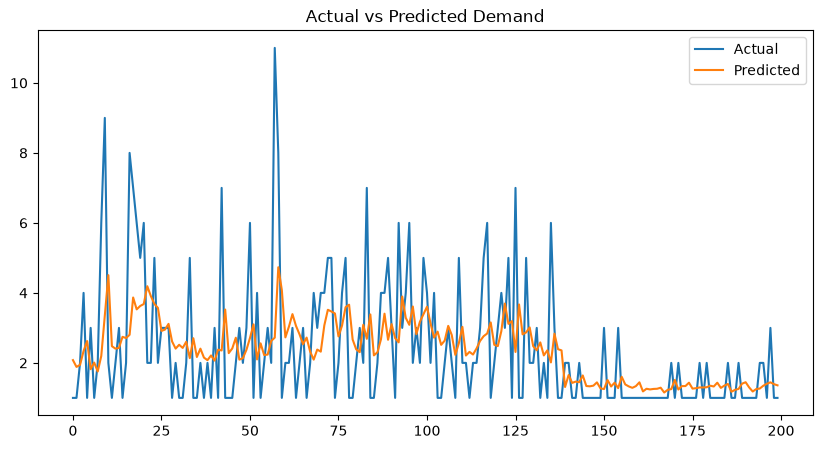

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

<Axes: xlabel='date'>

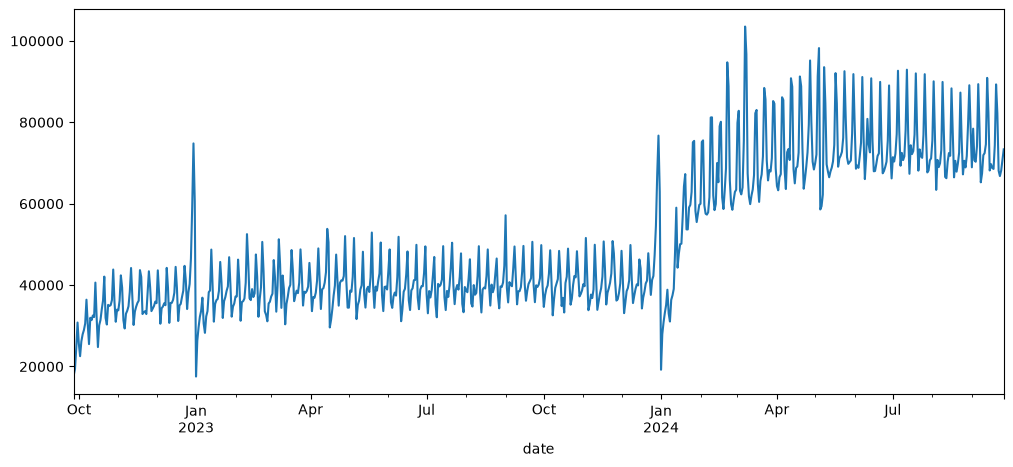

In [15]:
daily_sales = sales.groupby("date")["quantity"].sum()

daily_sales.plot(figsize=(12,5))


In [17]:
top_products = (
    sales.groupby("item_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

item_id
b0d24502fb66    1911737.000
9a7e315f3f42     529681.604
63161948a95a     420427.000
e5b2b6f57ea7     345117.000
0973df3ff57f     325319.859
b5aac3497e3f     217801.000
6d284b4e9982     188326.000
ad5239463b05     162980.000
5b8e114fdf6f     162372.088
9b4865c6faf1     160477.000
Name: quantity, dtype: float64

In [20]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})
importance

,feature,importance
0,item_id,1551
1,store_id,230
2,price_base,636
3,year,92
4,month,266
5,day,815
6,dayofweek,916
7,week,860
8,lag_1,1416
9,lag_7,659


In [23]:
errors = y_test - preds
errors

1136428   -1.078967
1141282   -0.885156
1146006    0.057395
1155920    1.662099
1161664   -1.624622
             ...   
7411105    0.478739
7416282   -0.406891
7421410   -0.497681
7426628    0.579841
7431912   -0.661418
Name: quantity, Length: 2225452, dtype: float64

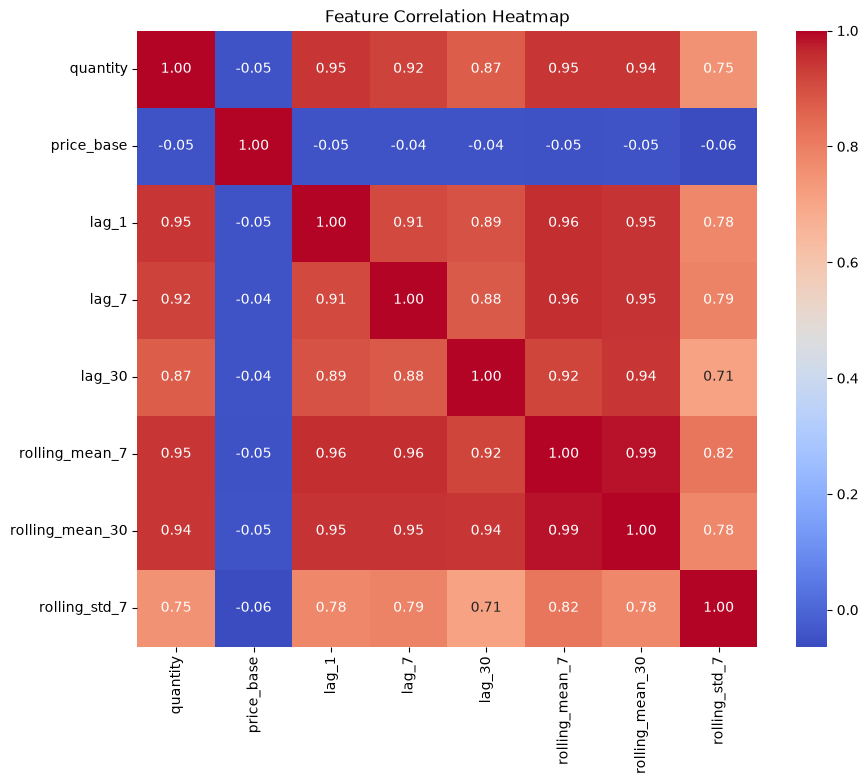

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    'quantity',
    'price_base',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30',
    'rolling_std_7'
]

corr_matrix = sales[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

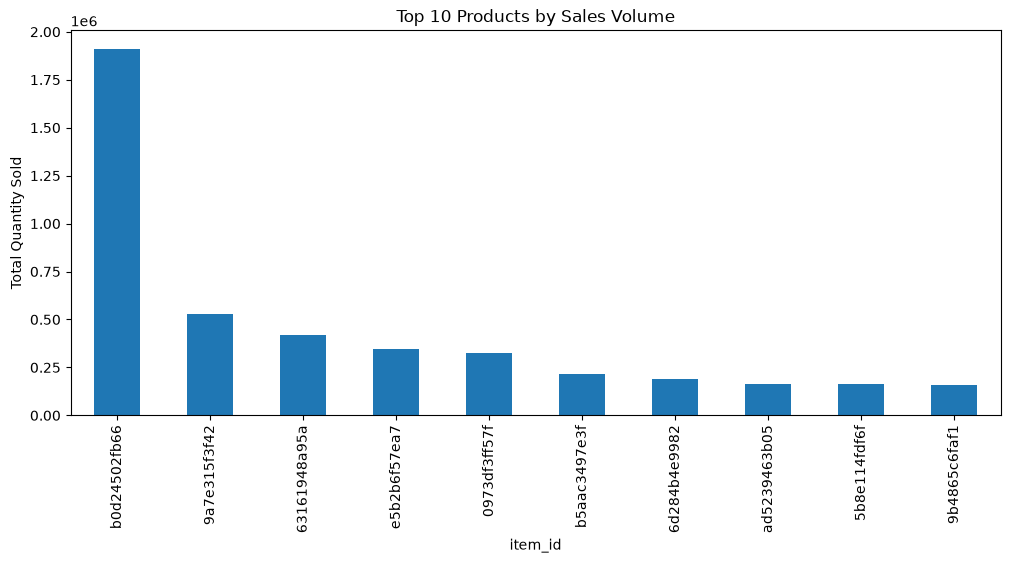

In [26]:
top_products = (
    sales.groupby('item_id')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title('Top 10 Products by Sales Volume')
plt.ylabel('Total Quantity Sold')

plt.show()

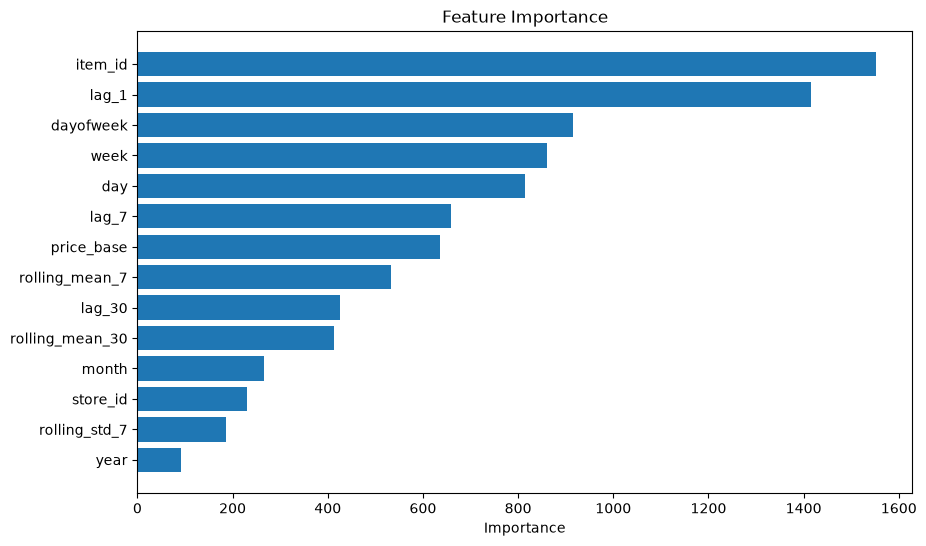

In [27]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Importance')

plt.gca().invert_yaxis()

plt.show()

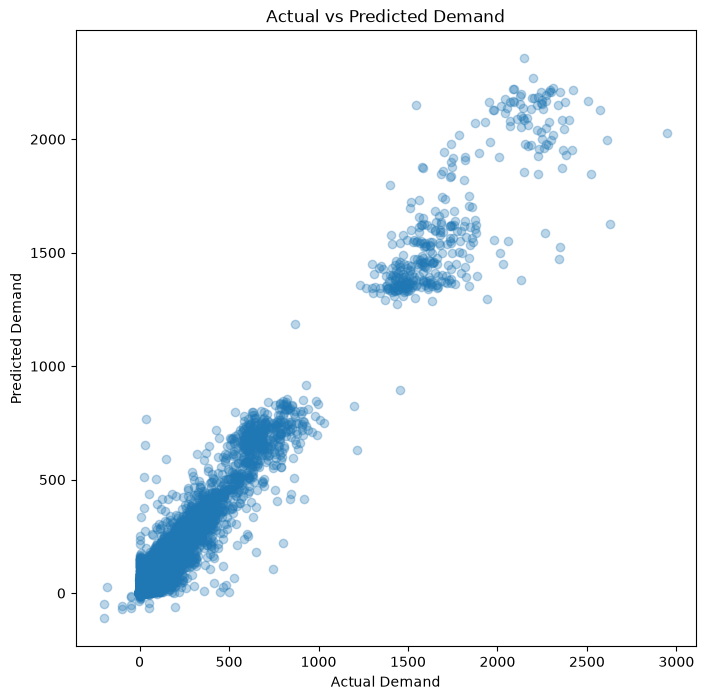

In [28]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    preds,
    alpha=0.3
)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

plt.title('Actual vs Predicted Demand')

plt.show()

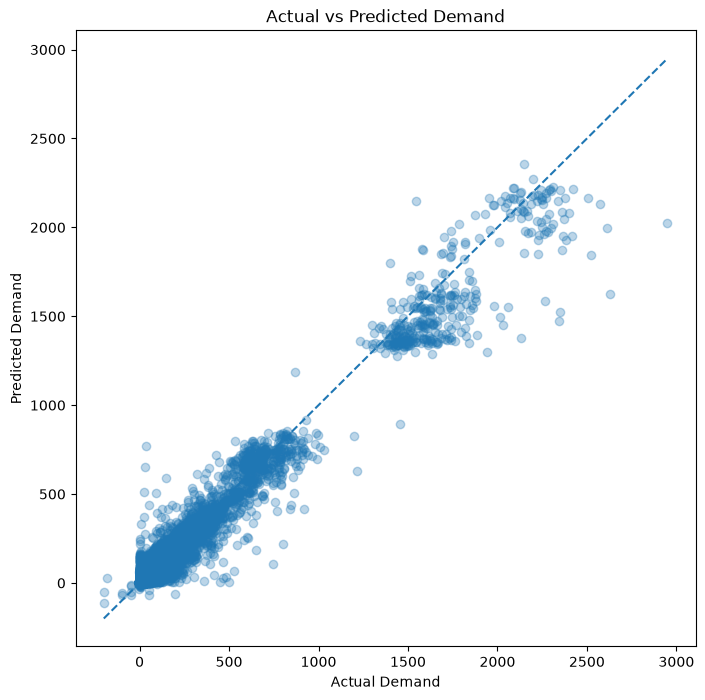

In [29]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    preds,
    alpha=0.3
)

min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())

plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    '--'
)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

plt.title('Actual vs Predicted Demand')

plt.show()

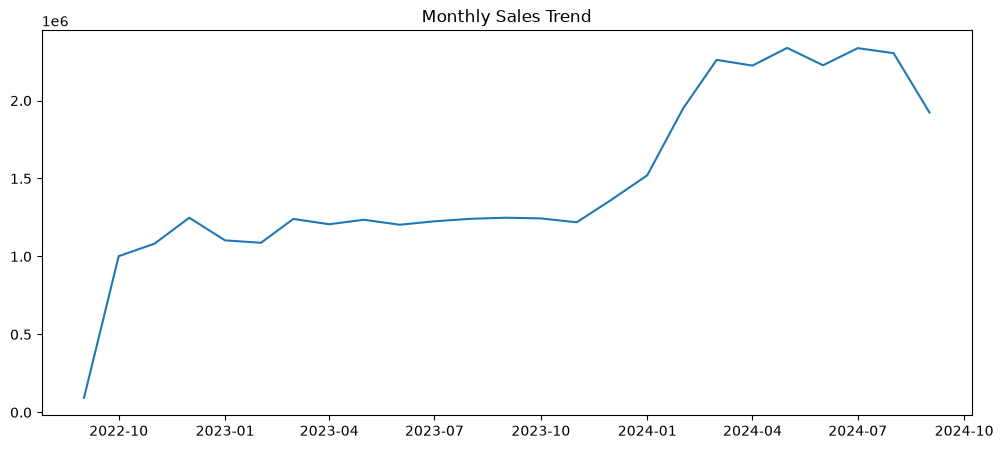

In [30]:
monthly_sales = (
    sales.groupby(['year','month'])['quantity']
    .sum()
    .reset_index()
)

monthly_sales['date'] = pd.to_datetime(
    monthly_sales[['year','month']]
    .assign(day=1)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['date'],
    monthly_sales['quantity']
)

plt.title('Monthly Sales Trend')

plt.show()